# Random Forest - BODMAS Malware Classification

## Algorithm Justification

Random Forest was selected as the second classifier for the following reasons:

- **Non-linear decision boundaries:** PE binary feature spaces contain complex, non-linear relationships between features that Logistic Regression cannot capture. Random Forest handles these naturally through deep tree splits.
- **No feature scaling required:** Unlike gradient-based methods, Random Forest is invariant to feature scale, so `StandardScaler` is not needed in the pipeline.
- **Robustness to noise and irrelevant features:** Bagging and random feature subsampling at each split (`max_features='sqrt'`) make Random Forest robust to noisy or redundant features, which are common in PE feature extraction.
- **Class imbalance:** `class_weight='balanced_subsample'` reweights classes within each bootstrap sample, which is more appropriate than global balancing for an ensemble method.
- **Strong empirical baseline:** Random Forest consistently performs well on tabular malware classification tasks and provides feature importance as a bonus interpretability tool.

In [ ]:
# ============================================================
# RANDOM FOREST NOTEBOOK
# ============================================================

import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# =========================
# CHANGE THIS MAIN PROJECT PATH
# =========================
from google.colab import drive
drive.mount('/content/drive')

# Change this to your actual Google Drive folder
PROJECT_DIR = "/content/drive/MyDrive/BODMAS_Assignment_Final"

# PROJECT_DIR = r"/Users/varunsp/Developer/Applications of Artificial Intelligence for Cyber Security/PY/Assignment-2_Final"

DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "randomforest")

os.makedirs(OUTPUT_DIR, exist_ok=True)

BODMAS_NPZ = os.path.join(DATA_DIR, "bodmas.npz")
METADATA_CSV = os.path.join(DATA_DIR, "bodmas_metadata.csv")
CATEGORY_CSV = os.path.join(DATA_DIR, "bodmas_malware_category.csv")

RANDOM_STATE = 42
TEST_SIZE = 0.20

print("Data folder:", DATA_DIR)
print("Random Forest output folder:", OUTPUT_DIR)

Mounted at /content/drive
Data folder: /content/drive/MyDrive/BODMAS_Assignment_Final/dataset
Random Forest output folder: /content/drive/MyDrive/BODMAS_Assignment_Final/randomforest


## Data Loading

The BODMAS dataset consists of three files:
- `bodmas.npz` - the pre-extracted numerical feature matrix `X`
- `bodmas_metadata.csv` - SHA256 hashes and file-level metadata for all samples
- `bodmas_malware_category.csv` - maps SHA256 hashes to malware family labels (malware only)

These are loaded separately and joined on the SHA256 column in the next step.

## Label Preparation

Labels are assigned by joining metadata with the category file on SHA256. Samples absent from the category file are benign by definition and are filled accordingly. The SHA column name is auto-detected to handle schema differences.

In [ ]:
# ============================================================
# LOAD DATA AND PREPARE CATEGORY LABELS
# ============================================================

print("=" * 80)
print("LOADING DATA")
print("=" * 80)

data = np.load(BODMAS_NPZ, allow_pickle=True)
X = data["X"]

metadata = pd.read_csv(METADATA_CSV)
categories = pd.read_csv(CATEGORY_CSV)

print("NPZ keys:", list(data.keys()))
print("Feature matrix shape:", X.shape)
print("Metadata shape:", metadata.shape)
print("Category file shape:", categories.shape)

print("\nMetadata columns:", metadata.columns.tolist())
print("Category columns:", categories.columns.tolist())

# =========================
# Correct label preparation
# =========================
metadata_sha_col = "sha256" if "sha256" in metadata.columns else "sha"
category_sha_col = "sha256" if "sha256" in categories.columns else "sha"

possible_category_cols = [
    col for col in categories.columns
    if col.lower() not in ["sha", "sha256"]
]

category_label_col = possible_category_cols[0]

print("\nUsing metadata SHA column:", metadata_sha_col)
print("Using category SHA column:", category_sha_col)
print("Using malware category column:", category_label_col)

category_map = categories.set_index(category_sha_col)[category_label_col]

df = metadata.copy()
df["malware_category"] = df[metadata_sha_col].map(category_map)

# Category file does not include benign programs
df["malware_category"] = df["malware_category"].fillna("benign")

y_text = df["malware_category"].astype(str).values

print("\nFinal X shape:", X.shape)
print("Final y shape:", y_text.shape)

print("\nClass distribution:")
class_distribution = pd.Series(y_text).value_counts()
display(class_distribution)

class_distribution.to_csv(os.path.join(OUTPUT_DIR, "rf_class_distribution.csv"))

LOADING DATA
NPZ keys: ['X', 'y']
Feature matrix shape: (134435, 2381)
Metadata shape: (134435, 3)
Category file shape: (57293, 2)

Metadata columns: ['sha', 'timestamp', 'family']
Category columns: ['sha256', 'category']

Using metadata SHA column: sha
Using category SHA column: sha256
Using malware category column: category

Final X shape: (134435, 2381)
Final y shape: (134435,)

Class distribution:


,count
benign,77142
trojan,29972
worm,16697
backdoor,7331
downloader,1031
ransomware,821
dropper,715
informationstealer,448
virus,192
pua,29


## Evaluation Helper Functions

Two helper functions are defined here and reused throughout:

- `calculate_tpr_fpr` - computes per-class True Positive Rate (TPR = TP / (TP + FN)) and False Positive Rate (FPR = FP / (FP + TN)) using a one-vs-rest breakdown of the confusion matrix.
- `evaluate_model` - runs prediction on a given split, prints overall accuracy, balanced accuracy, the full classification report, and calls `calculate_tpr_fpr` for per-class detail.

Balanced accuracy is reported alongside overall accuracy because the BODMAS dataset is class-imbalanced - overall accuracy alone would be misleading.

In [ ]:
# ============================================================
# LABEL ENCODING AND TRAIN-TEST SPLIT
# ============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

class_names = list(label_encoder.classes_)

print("Classes:")
for idx, name in enumerate(class_names):
    print(idx, "->", name)

# Save label encoder for holdout notebook
joblib.dump(label_encoder, os.path.join(OUTPUT_DIR, "label_encoder.joblib"))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class distribution:")
display(pd.Series(label_encoder.inverse_transform(y_train)).value_counts())

print("\nTesting class distribution:")
display(pd.Series(label_encoder.inverse_transform(y_test)).value_counts())

Classes:
0 -> backdoor
1 -> benign
2 -> cryptominer
3 -> downloader
4 -> dropper
5 -> exploit
6 -> informationstealer
7 -> p2p-worm
8 -> pua
9 -> ransomware
10 -> rootkit
11 -> trojan
12 -> trojan-gamethief
13 -> virus
14 -> worm

Train shape: (107548, 2381)
Test shape: (26887, 2381)

Training class distribution:


,count
benign,61714
trojan,23977
worm,13358
backdoor,5865
downloader,825
ransomware,657
dropper,572
informationstealer,358
virus,153
pua,23



Testing class distribution:


,count
benign,15428
trojan,5995
worm,3339
backdoor,1466
downloader,206
ransomware,164
dropper,143
informationstealer,90
virus,39
pua,6


## Evaluation Helper Functions

Two helper functions are defined here and reused throughout:

- `calculate_tpr_fpr` - computes per-class True Positive Rate (TPR = TP / (TP + FN)) and False Positive Rate (FPR = FP / (FP + TN)) using a one-vs-rest breakdown of the confusion matrix.
- `evaluate_model` - runs prediction on a given split, prints overall accuracy, balanced accuracy, the full classification report, and calls `calculate_tpr_fpr` for per-class detail.

Balanced accuracy is reported alongside overall accuracy because the BODMAS dataset is class-imbalanced - overall accuracy alone would be misleading.

In [ ]:
# ============================================================
# EVALUATION HELPER FUNCTIONS
# ============================================================

def calculate_tpr_fpr(y_true, y_pred, class_names):
    """
    One-vs-rest TPR and FPR for each class.

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)
    """
    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    rows = []

    for i, class_name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        rows.append({
            "class": class_name,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "TPR": TPR,
            "FPR": FPR
        })

    return pd.DataFrame(rows)


def evaluate_model(model, X_data, y_data, split_name):
    print("=" * 80)
    print(f"RANDOM FOREST EVALUATION ON {split_name.upper()}")
    print("=" * 80)

    y_pred = model.predict(X_data)

    accuracy = accuracy_score(y_data, y_pred)
    balanced_acc = balanced_accuracy_score(y_data, y_pred)

    print("Overall Accuracy:", round(accuracy, 4))
    print("Balanced Accuracy:", round(balanced_acc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_data,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    tpr_fpr_df = calculate_tpr_fpr(y_data, y_pred, class_names)

    print("\nTPR and FPR per class:")
    display(tpr_fpr_df)

    return {
        "split": split_name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "predictions": y_pred,
        "tpr_fpr": tpr_fpr_df
    }

## Hyperparameter Tuning

`RandomizedSearchCV` with 8 iterations and 2-fold CV on a 25% stratified subsample of training data. Random search is preferred here because the Random Forest search space is large - an exhaustive grid over `n_estimators × max_depth × min_samples_split × min_samples_leaf × max_features` would be computationally prohibitive.

Key hyperparameters being tuned:
- **`n_estimators`** - more trees reduce variance but increase training time
- **`max_depth`** - controls individual tree complexity; `None` allows full growth
- **`min_samples_split` / `min_samples_leaf`** - regularise tree depth implicitly by requiring minimum sample counts at nodes
- **`max_features`** - controls feature subsampling per split; `sqrt` and `log2` both reduce correlation between trees

Scoring is balanced accuracy to avoid the benign-class majority dominating the metric.

In [ ]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

TUNE_SIZE = 0.25

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=TUNE_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Tuning subset shape:", X_tune.shape)

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold()),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 30, 50, 70],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=8,
    scoring="balanced_accuracy",
    cv=2,
    verbose=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start_time = time.time()

rf_search.fit(X_tune, y_tune)

end_time = time.time()

print("\nRandom Forest tuning completed.")
print("Tuning time:", round((end_time - start_time) / 60, 2), "minutes")
print("Best parameters:")
print(rf_search.best_params_)
print("Best CV balanced accuracy:", rf_search.best_score_)

Tuning subset shape: (26887, 2381)
Fitting 2 folds for each of 8 candidates, totalling 16 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(



Random Forest tuning completed.
Tuning time: 2.79 minutes
Best parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30}
Best CV balanced accuracy: 0.571038205917811


## Final Model Training

The final pipeline is trained on the **complete training split**. The pipeline steps are:
1. **`SimpleImputer(strategy='median')`** - fills missing values with the column median, robust to outliers in PE feature vectors.
2. **`VarianceThreshold()`** - removes zero-variance features that add noise without discriminative value.
3. **`RandomForestClassifier`** - 2000 trees with full depth (`max_depth=None`), `max_features='sqrt'`, and `class_weight='balanced_subsample'`.

`n_estimators=2000` is used for the final model (higher than the tuning search range) to maximise ensemble stability. No `StandardScaler` is needed as Random Forest is scale-invariant.


In [ ]:
# ============================================================
# TRAIN FINAL RANDOM FOREST MODEL
# ============================================================

best_params = rf_search.best_params_

rf_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold()),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
        n_estimators=best_params["classifier__n_estimators"],
        max_depth=best_params["classifier__max_depth"],
        min_samples_split=best_params["classifier__min_samples_split"],
        min_samples_leaf=best_params["classifier__min_samples_leaf"],
        max_features=best_params["classifier__max_features"]
    ))
])

print("=" * 80)
print("TRAINING FINAL RANDOM FOREST MODEL")
print("=" * 80)

start_time = time.time()

rf_final.fit(X_train, y_train)

end_time = time.time()

training_time_minutes = round((end_time - start_time) / 60, 2)

print("Training completed.")
print("Training time:", training_time_minutes, "minutes")

# Save final model
model_path = os.path.join(OUTPUT_DIR, "random_forest_model.joblib")
joblib.dump(rf_final, model_path)

print("Saved model to:", model_path)

# Save best hyperparameters
best_params_path = os.path.join(OUTPUT_DIR, "random_forest_best_params.txt")

with open(best_params_path, "w") as f:
    f.write(str(best_params))
    f.write("\n")
    f.write("Best CV balanced accuracy: " + str(rf_search.best_score_))
    f.write("\n")
    f.write("Training time minutes: " + str(training_time_minutes))

print("Saved best parameters to:", best_params_path)

TRAINING FINAL RANDOM FOREST MODEL
Training completed.
Training time: 2.84 minutes
Saved model to: /content/drive/MyDrive/BODMAS_Assignment_Final/randomforest/random_forest_model.joblib
Saved best parameters to: /content/drive/MyDrive/BODMAS_Assignment_Final/randomforest/random_forest_best_params.txt


## Model Evaluation - Train and Test Splits

The model is evaluated on both splits. Training accuracy for Random Forest is expected to be very high (near-perfect) due to full-depth trees; the test set result is the meaningful generalisation estimate.

Metrics reported:
- **Overall Accuracy**
- **Balanced Accuracy**
- **Classification Report** (precision, recall, F1 per class)
- **TPR and FPR per class** (saved to CSV)

In [ ]:
# ============================================================
# EVALUATE RANDOM FOREST
# ============================================================

rf_train_results = evaluate_model(
    rf_final,
    X_train,
    y_train,
    "training set"
)

rf_test_results = evaluate_model(
    rf_final,
    X_test,
    y_test,
    "testing set"
)

# Save TPR/FPR results
rf_train_results["tpr_fpr"].to_csv(
    os.path.join(OUTPUT_DIR, "rf_train_tpr_fpr.csv"),
    index=False
)

rf_test_results["tpr_fpr"].to_csv(
    os.path.join(OUTPUT_DIR, "rf_test_tpr_fpr.csv"),
    index=False
)

# Save summary
rf_summary = pd.DataFrame([
    {
        "model": "Random Forest",
        "split": "training",
        "accuracy": rf_train_results["accuracy"],
        "balanced_accuracy": rf_train_results["balanced_accuracy"]
    },
    {
        "model": "Random Forest",
        "split": "testing",
        "accuracy": rf_test_results["accuracy"],
        "balanced_accuracy": rf_test_results["balanced_accuracy"]
    }
])

display(rf_summary)

rf_summary.to_csv(
    os.path.join(OUTPUT_DIR, "rf_results_summary.csv"),
    index=False
)

RANDOM FOREST EVALUATION ON TRAINING SET
Overall Accuracy: 0.9861
Balanced Accuracy: 0.9949

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.94      1.00      0.97      5865
            benign       1.00      1.00      1.00     61714
       cryptominer       0.84      1.00      0.91        16
        downloader       0.91      1.00      0.95       825
           dropper       0.79      1.00      0.88       572
           exploit       1.00      1.00      1.00        10
informationstealer       0.93      1.00      0.96       358
          p2p-worm       0.72      1.00      0.84        13
               pua       0.96      1.00      0.98        23
        ransomware       0.89      1.00      0.94       657
           rootkit       1.00      1.00      1.00         2
            trojan       0.99      0.95      0.97     23977
  trojan-gamethief       1.00      1.00      1.00         5
             virus       0.99      1.00    

,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,5843,350,101333,22,0.996249,0.003442
1,benign,61697,109,45725,17,0.999725,0.002378
2,cryptominer,16,3,107529,0,1.000000,0.000028
3,downloader,824,83,106640,1,0.998788,0.000778
4,dropper,571,149,106827,1,0.998252,0.001393
5,exploit,10,0,107538,0,1.000000,0.000000
6,informationstealer,358,28,107162,0,1.000000,0.000261
7,p2p-worm,13,5,107530,0,1.000000,0.000046
8,pua,23,1,107524,0,1.000000,0.000009
9,ransomware,655,82,106809,2,0.996956,0.000767


RANDOM FOREST EVALUATION ON TESTING SET
Overall Accuracy: 0.9686
Balanced Accuracy: 0.662

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.94      0.97      0.95      1466
            benign       0.99      1.00      0.99     15428
       cryptominer       0.75      0.75      0.75         4
        downloader       0.87      0.88      0.87       206
           dropper       0.65      0.85      0.74       143
           exploit       1.00      1.00      1.00         2
informationstealer       0.82      0.79      0.80        90
          p2p-worm       0.00      0.00      0.00         3
               pua       0.00      0.00      0.00         6
        ransomware       0.83      0.90      0.86       164
           rootkit       0.00      0.00      0.00         1
            trojan       0.97      0.91      0.94      5995
  trojan-gamethief       0.00      0.00      0.00         1
             virus       1.00      0.92      

,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,1426,97,25324,40,0.972715,0.003816
1,benign,15407,175,11284,21,0.998639,0.015272
2,cryptominer,3,1,26882,1,0.750000,0.000037
3,downloader,181,28,26653,25,0.878641,0.001049
4,dropper,122,65,26679,21,0.853147,0.002430
5,exploit,2,0,26885,0,1.000000,0.000000
6,informationstealer,71,16,26781,19,0.788889,0.000597
7,p2p-worm,0,2,26882,3,0.000000,0.000074
8,pua,0,0,26881,6,0.000000,0.000000
9,ransomware,147,31,26692,17,0.896341,0.001160


,model,split,accuracy,balanced_accuracy
0,Random Forest,training,0.986081,0.994917
1,Random Forest,testing,0.968609,0.662029


## Confusion Matrices

Raw and row-normalised confusion matrices are plotted for the test set. The normalised matrix is particularly useful here given the large class count - it shows which malware families are most frequently misclassified and whether confusions are symmetric or directional.

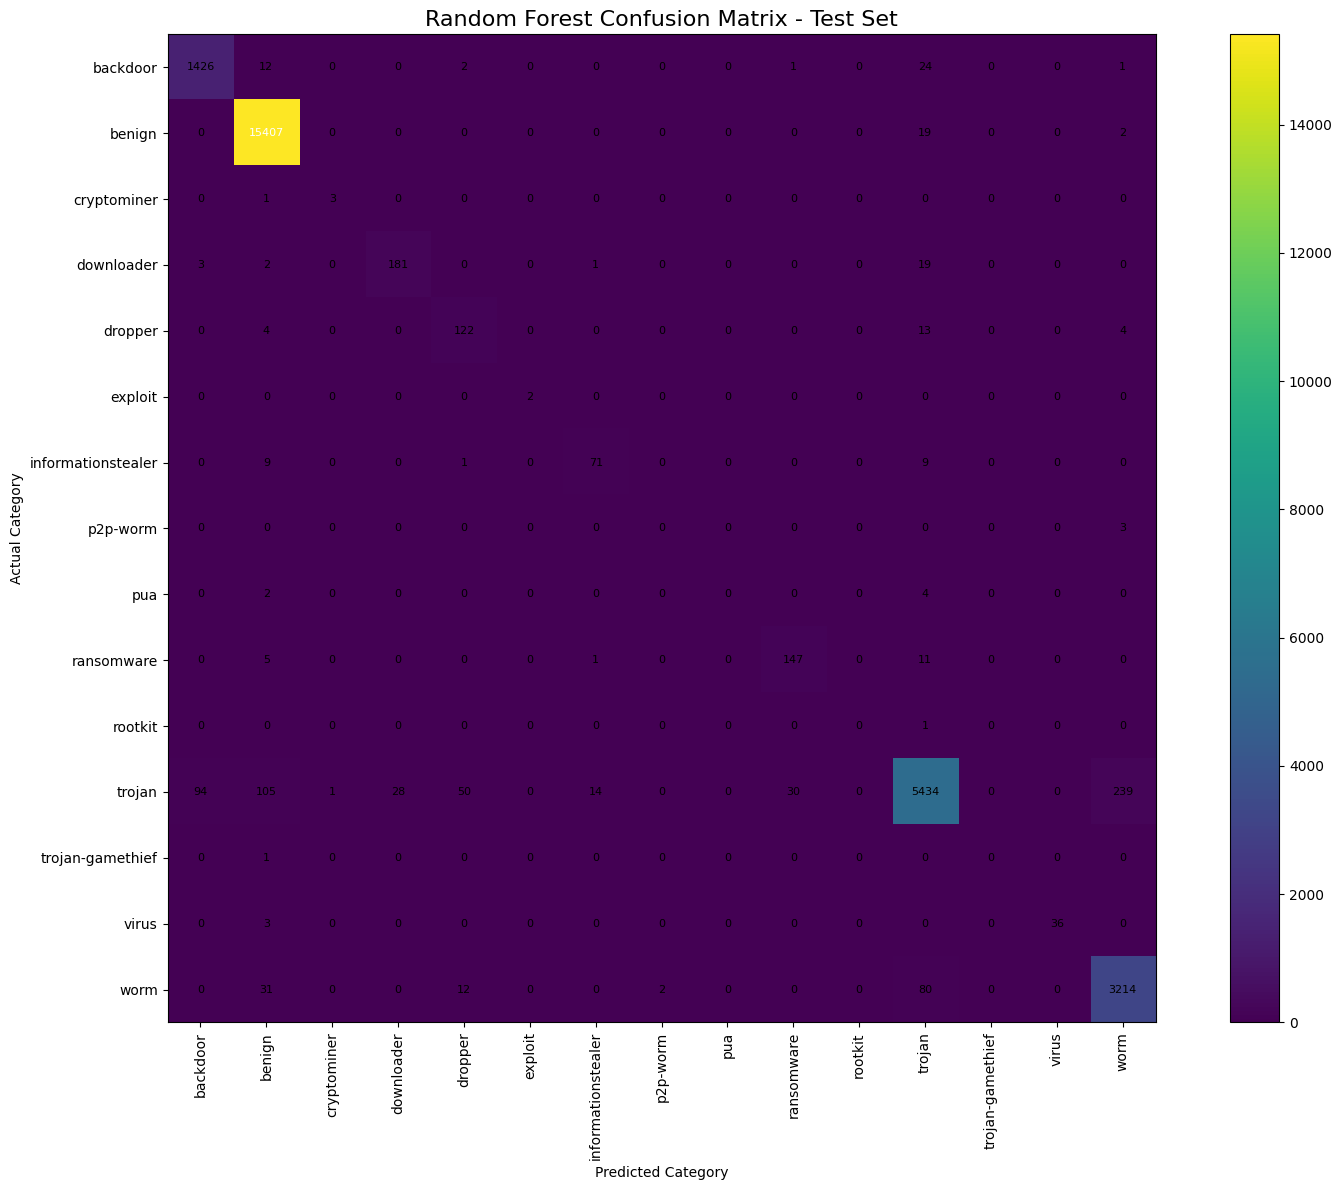

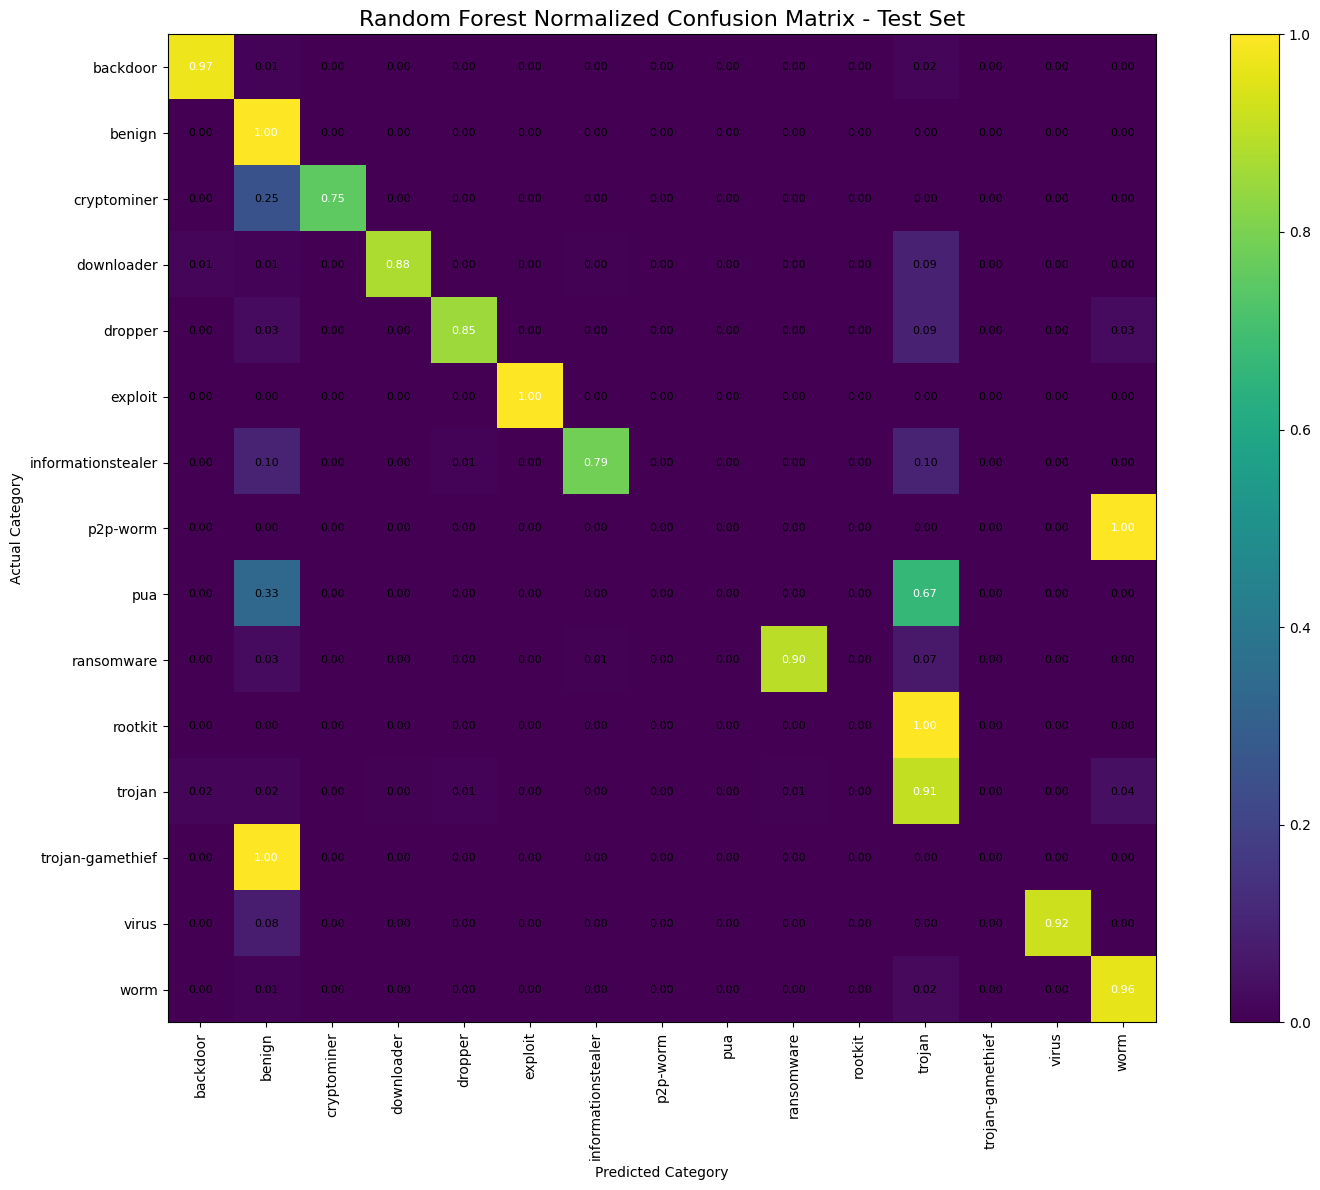

In [ ]:
# ============================================================
# CONFUSION MATRIX IMAGES
# ============================================================

def plot_confusion_matrix_image(y_true, y_pred, title, normalize=False):
    labels = np.arange(len(class_names))

    if normalize:
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=labels,
            normalize="true"
        )
        fmt = ".2f"
    else:
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=labels
        )
        fmt = "d"

    plt.figure(figsize=(16, 12))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title, fontsize=16)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = format(cm[i, j], fmt)
            plt.text(
                j,
                i,
                value,
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=8
            )

    plt.ylabel("Actual Category")
    plt.xlabel("Predicted Category")
    plt.tight_layout()
    plt.show()


# Test set confusion matrix
plot_confusion_matrix_image(
    y_test,
    rf_test_results["predictions"],
    "Random Forest Confusion Matrix - Test Set",
    normalize=False
)

# Normalized test set confusion matrix
plot_confusion_matrix_image(
    y_test,
    rf_test_results["predictions"],
    "Random Forest Normalized Confusion Matrix - Test Set",
    normalize=True
)

## Sample Prediction Check

Predictions on 30 randomly selected samples to verify the end-to-end pipeline - feature input through imputation, variance filtering, and classification - produces correct label outputs.

In [ ]:
# ============================================================
# CHECK RANDOM FOREST ON REAL SAMPLE ROWS
# ============================================================

N_SAMPLES = 30
rng = np.random.default_rng(RANDOM_STATE)

sample_indices = rng.choice(X.shape[0], size=N_SAMPLES, replace=False)

X_sample = X[sample_indices]
y_sample_true = y[sample_indices]

rf_sample_pred = rf_final.predict(X_sample)

sample_results = pd.DataFrame({
    "sample_index": sample_indices,
    "sha": df.iloc[sample_indices][metadata_sha_col].values,
    "actual_category": label_encoder.inverse_transform(y_sample_true),
    "predicted_category": label_encoder.inverse_transform(rf_sample_pred),
})

sample_results["correct"] = (
    sample_results["actual_category"] == sample_results["predicted_category"]
)

display(sample_results)

sample_accuracy = accuracy_score(y_sample_true, rf_sample_pred)

print("Random Forest accuracy on selected samples:", round(sample_accuracy, 4))
print("Correct predictions:", sample_results["correct"].sum(), "/", N_SAMPLES)

,sample_index,sha,actual_category,predicted_category,correct
0,86555,f61e47ff46c2029eb735df3d1eb6243196d4421c4ddc77...,benign,benign,True
1,70767,37f04f611715c86b6225faa7db02078f678a1ab086795b...,trojan,trojan,True
2,58201,8eb1bc75eea45ab42df04f28f80865bb5d8fa2c7d87e41...,worm,worm,True
3,115405,792d9e48ead3ace6282e25877450e9bda0bdedd066d93e...,benign,benign,True
4,11995,62ac3e52f1645ad2f35c3024b528f1f2902129221aef48...,benign,benign,True
5,12658,7a56ddb4e7fcc728286dc2d9dafcc0b869a50762b7d579...,benign,benign,True
6,24539,8e0ddde2f1456dc3f4bb5fa7d27a6c95d61726e67f8872...,trojan,trojan,True
7,110606,fb35b311e6ab34db6748d605662114cbd20e5eefb5522b...,benign,benign,True
8,105663,f15d7d9fe1f17214735eaae84df7b2f242199255d0367c...,benign,benign,True
9,93735,535582b8385115e6f8fd963de93f3fad4e70e66c5dc047...,benign,benign,True


Random Forest accuracy on selected samples: 1.0
Correct predictions: 30 / 30


## Holdout Dataset Evaluation

The trained Random Forest model and label encoder are loaded from disk. Holdout labels are prepared using the same SHA256 join and benign-fill logic. An unknown-class check is run before encoding to catch any label mismatches early.

The holdout results represent the model's performance on completely unseen data, giving the most realistic estimate of deployment performance.

RF model: /content/drive/MyDrive/BODMAS_Assignment_Final/randomforest/random_forest_model.joblib
Label encoder: /content/drive/MyDrive/BODMAS_Assignment_Final/randomforest/label_encoder.joblib
Holdout NPZ: /content/drive/MyDrive/BODMAS_Assignment_Final/HoldOutDataSet/bodmas_holdout.npz

Random Forest model loaded.
Classes: ['backdoor', 'benign', 'cryptominer', 'downloader', 'dropper', 'exploit', 'informationstealer', 'p2p-worm', 'pua', 'ransomware', 'rootkit', 'trojan', 'trojan-gamethief', 'virus', 'worm']

Holdout X shape: (34435, 2381)
Holdout metadata shape: (34435, 3)
Holdout category shape: (57293, 2)

Holdout class distribution:


,count
benign,18363
trojan,6724
worm,6145
backdoor,2666
informationstealer,217
dropper,135
ransomware,105
downloader,55
p2p-worm,13
pua,9



Encoded holdout y shape: (34435,)

Running Random Forest on holdout dataset...

RANDOM FOREST HOLDOUT RESULTS
Overall Accuracy: 0.985
Balanced Accuracy: 0.9482

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.98      0.99      0.99      2666
            benign       1.00      1.00      1.00     18363
       cryptominer       1.00      1.00      1.00         1
        downloader       0.87      0.95      0.90        55
           dropper       0.73      0.96      0.83       135
           exploit       0.00      0.00      0.00         0
informationstealer       0.97      0.99      0.98       217
          p2p-worm       0.65      0.85      0.73        13
               pua       0.88      0.78      0.82         9
        ransomware       0.88      0.93      0.91       105
           rootkit       0.00      0.00      0.00         0
            trojan       0.99      0.94      0.96      6724
  trojan-gamethief       1.00     

,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,2652,58,31711,14,0.994749,0.001826
1,benign,18362,49,16023,1,0.999946,0.003049
2,cryptominer,1,0,34434,0,1.000000,0.000000
3,downloader,52,8,34372,3,0.945455,0.000233
4,dropper,130,47,34253,5,0.962963,0.001370
5,exploit,0,0,34435,0,0.000000,0.000000
6,informationstealer,215,6,34212,2,0.990783,0.000175
7,p2p-worm,11,6,34416,2,0.846154,0.000174
8,pua,7,1,34425,2,0.777778,0.000029
9,ransomware,98,13,34317,7,0.933333,0.000379


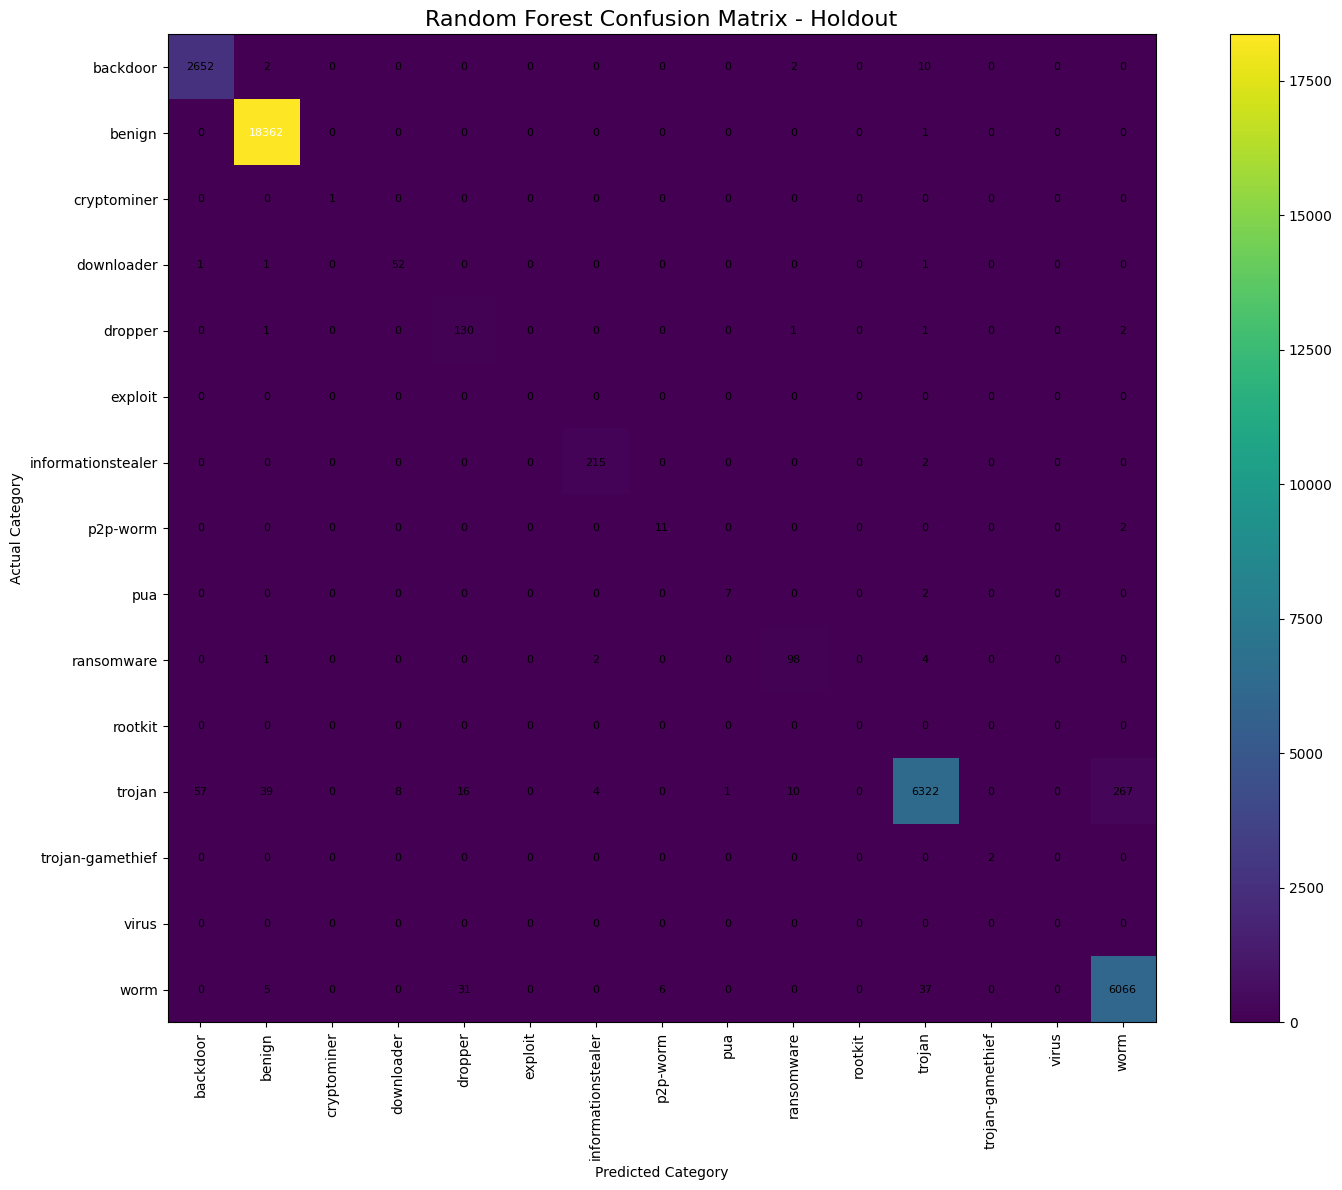

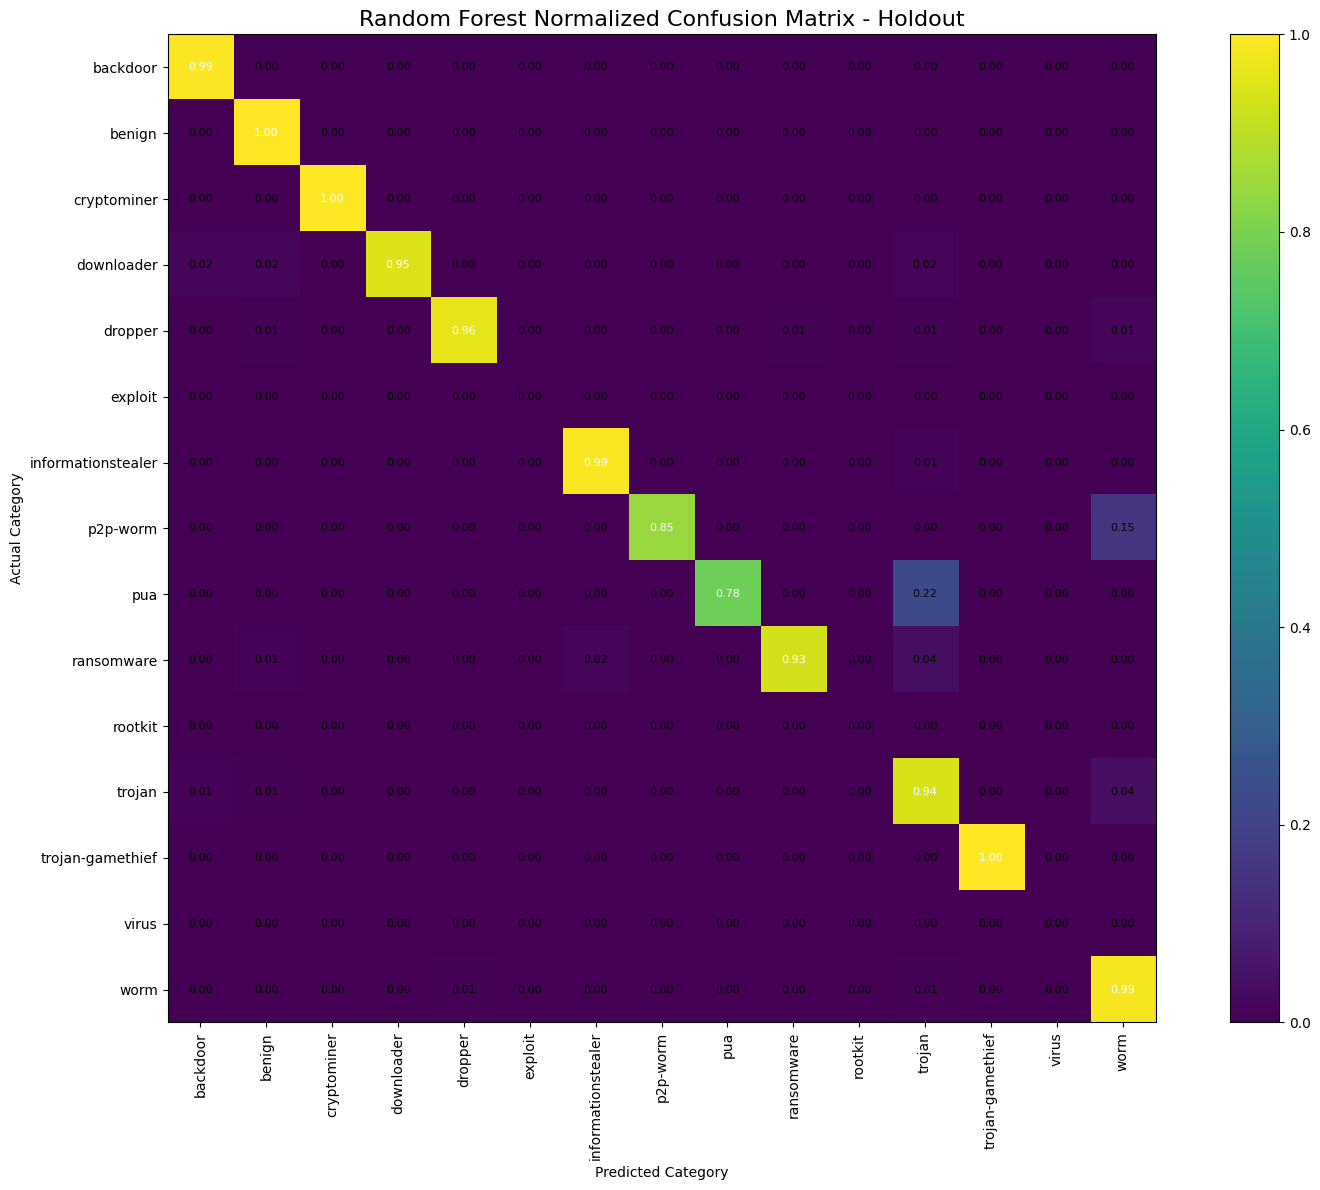

In [ ]:
# ============================================================
# RANDOM FOREST - HOLDOUT DATASET EVALUATION
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/BODMAS_Assignment_Final"

HOLDOUT_DIR = os.path.join(PROJECT_DIR, "HoldOutDataSet")
RF_DIR = os.path.join(PROJECT_DIR, "randomforest")

HOLDOUT_NPZ = os.path.join(HOLDOUT_DIR, "bodmas_holdout.npz")
HOLDOUT_METADATA_CSV = os.path.join(HOLDOUT_DIR, "bodmas_metadata_holdout.csv")
HOLDOUT_CATEGORY_CSV = os.path.join(HOLDOUT_DIR, "bodmas_malware_category.csv")

RF_MODEL_PATH = os.path.join(RF_DIR, "random_forest_model.joblib")
LABEL_ENCODER_PATH = os.path.join(RF_DIR, "label_encoder.joblib")

print("RF model:", RF_MODEL_PATH)
print("Label encoder:", LABEL_ENCODER_PATH)
print("Holdout NPZ:", HOLDOUT_NPZ)

# ============================================================
# LOAD TRAINED RANDOM FOREST MODEL
# ============================================================

rf_model = joblib.load(RF_MODEL_PATH)
label_encoder = joblib.load(LABEL_ENCODER_PATH)

class_names = list(label_encoder.classes_)

print("\nRandom Forest model loaded.")
print("Classes:", class_names)

# ============================================================
# LOAD HOLDOUT DATA
# ============================================================

holdout_data = np.load(HOLDOUT_NPZ, allow_pickle=True)
X_holdout = holdout_data["X"]

holdout_metadata = pd.read_csv(HOLDOUT_METADATA_CSV)
holdout_categories = pd.read_csv(HOLDOUT_CATEGORY_CSV)

print("\nHoldout X shape:", X_holdout.shape)
print("Holdout metadata shape:", holdout_metadata.shape)
print("Holdout category shape:", holdout_categories.shape)

# ============================================================
# PREPARE HOLDOUT CATEGORY LABELS
# ============================================================

metadata_sha_col = "sha256" if "sha256" in holdout_metadata.columns else "sha"
category_sha_col = "sha256" if "sha256" in holdout_categories.columns else "sha"

category_label_col = [
    c for c in holdout_categories.columns
    if c.lower() not in ["sha", "sha256"]
][0]

category_map = holdout_categories.set_index(category_sha_col)[category_label_col]

holdout_df = holdout_metadata.copy()
holdout_df["malware_category"] = holdout_df[metadata_sha_col].map(category_map)

# Missing category means benign
holdout_df["malware_category"] = holdout_df["malware_category"].fillna("benign")

y_holdout_text = holdout_df["malware_category"].astype(str).values

print("\nHoldout class distribution:")
display(pd.Series(y_holdout_text).value_counts())

# Check unknown labels
unknown_classes = set(y_holdout_text) - set(class_names)

if unknown_classes:
    raise ValueError(f"Unknown classes in holdout not seen during training: {unknown_classes}")

y_holdout = label_encoder.transform(y_holdout_text)

print("\nEncoded holdout y shape:", y_holdout.shape)

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def calculate_tpr_fpr(y_true, y_pred, class_names):
    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    rows = []

    for i, class_name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        rows.append({
            "class": class_name,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "TPR": TPR,
            "FPR": FPR
        })

    return pd.DataFrame(rows)


def plot_confusion_matrix_image(y_true, y_pred, title, normalize=False):
    labels = np.arange(len(class_names))

    if normalize:
        cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
        fmt = ".2f"
    else:
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        fmt = "d"

    plt.figure(figsize=(16, 12))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title, fontsize=16)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)

    threshold = cm.max() / 2 if cm.max() > 0 else 0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                format(cm[i, j], fmt),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=8
            )

    plt.ylabel("Actual Category")
    plt.xlabel("Predicted Category")
    plt.tight_layout()
    plt.show()

# ============================================================
# RANDOM FOREST HOLDOUT PREDICTION
# ============================================================

print("\nRunning Random Forest on holdout dataset...")

rf_pred = rf_model.predict(X_holdout)

rf_accuracy = accuracy_score(y_holdout, rf_pred)
rf_balanced_accuracy = balanced_accuracy_score(y_holdout, rf_pred)

print("\n" + "=" * 80)
print("RANDOM FOREST HOLDOUT RESULTS")
print("=" * 80)

print("Overall Accuracy:", round(rf_accuracy, 4))
print("Balanced Accuracy:", round(rf_balanced_accuracy, 4))

print("\nClassification Report:")
print(classification_report(
    y_holdout,
    rf_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0
))

rf_tpr_fpr = calculate_tpr_fpr(y_holdout, rf_pred, class_names)

print("\nTPR and FPR per class:")
display(rf_tpr_fpr)

# Confusion matrix images
plot_confusion_matrix_image(
    y_holdout,
    rf_pred,
    "Random Forest Confusion Matrix - Holdout",
    normalize=False
)

plot_confusion_matrix_image(
    y_holdout,
    rf_pred,
    "Random Forest Normalized Confusion Matrix - Holdout",
    normalize=True
)
